<a href="https://colab.research.google.com/github/shubhammadane/Deep-Learning-Project/blob/main/Perceptron_Loss_function_by_Shubham_Madane.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [10]:
from sklearn.datasets import make_classification
import numpy as np

# Generate synthetic data for binary classification
# n_samples: number of samples
# n_features: total number of features
# n_informative: number of informative features
# n_redundant: number of redundant features
# n_classes: number of classes
# n_clusters_per_class: number of clusters per class
# random_state: seed for reproducibility
# hypercube: if True, samples are drawn from a hypercube
# class_sep: how separated the classes are

X, y = make_classification(n_samples=100, n_features=2, n_informative=1,n_redundant=0,
                           n_classes=2, n_clusters_per_class=1, random_state=41,hypercube=False,class_sep=15)

In [11]:
# Display the shape of the feature matrix X (number of samples, number of features)
X.shape

(100, 2)

In [12]:
# Display the shape of the target vector y (number of samples)
y.shape

(100,)

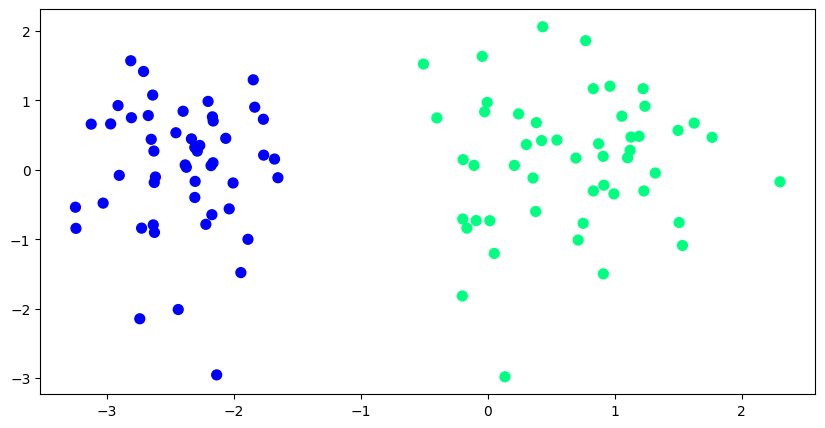

In [24]:
import matplotlib.pyplot as plt

# Create a figure for plotting
plt.figure(figsize=(10,5))

# Scatter plot the data points
# X[:,0]: all rows, first column (x-coordinates)
# X[:,1]: all rows, second column (y-coordinates)
# c=y: color points based on their class (y values)
# cmap='winter': colormap to use for coloring
# s=100: size of the markers
plt.scatter(X[:,0],X[:,1],c=y,cmap='winter',s=50)

In [14]:
def perceptron(X,y):
    # Initialize weights (w1, w2) and bias (b) to 1
    w1=w2=b=1
    # Set learning rate
    lr = 0.1

    # Iterate for a fixed number of epochs (1000 in this case)
    for j in range(1000):

        # Iterate through each data point
        for i in range(X.shape[0]):

            # Calculate the weighted sum (z) including bias
            z = w1*X[i][0] + w2*X[i][1] + b

            # Perceptron update rule: if z*y[i] < 0, misclassified point
            if z*y[i] < 0:
                # Update weights and bias
                w1 = w1 + lr*y[i]*X[i][0]
                w2 = w2 + lr*y[i]*X[i][1]
                b = b + lr*y[i]

    # Return the final weights and bias
    return w1,w2,b

In [15]:
# Call the perceptron function to train the model and get the final weights and bias
w1,w2,b = perceptron(X,y)

In [25]:
w1


np.float64(1.006638570722407)

In [28]:
w2

np.float64(0.22215119727529098)

In [16]:
# Display the learned bias 'b'
b

np.float64(1.3000000000000003)

In [17]:
# Calculate the slope (m) and y-intercept (c) of the decision boundary line
# The decision boundary is given by w1*x + w2*y + b = 0, which can be rewritten as y = -(w1/w2)*x - (b/w2)
m = -(w1/w2)
c = -(b/w2)

# Print the calculated slope and intercept
print(m,c)

-4.531321834268464 -5.851870329508209


(-3.0, 2.0)

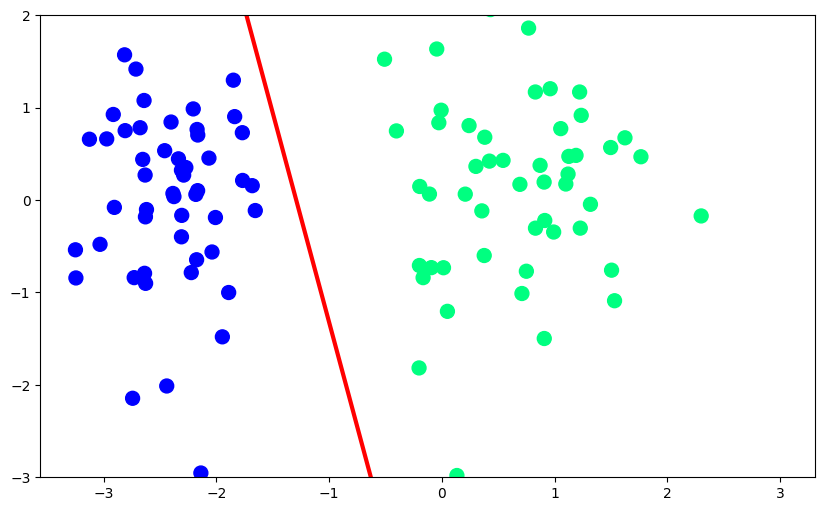

In [18]:
import numpy as np
import matplotlib.pyplot as plt

# Generate a range of x values for plotting the decision boundary
x_input = np.linspace(-3,3,100)
# Calculate corresponding y values using the learned slope (m) and intercept (c)
y_input = m*x_input + c

# Create a new figure for plotting
plt.figure(figsize=(10,6))

# Plot the decision boundary line
plt.plot(x_input,y_input,color='red',linewidth=3)

# Scatter plot the original data points again
plt.scatter(X[:,0],X[:,1],c=y,cmap='winter',s=100)

# Set the y-axis limits for better visualization
plt.ylim(-3,2)